# MNIST Logic Model With Custom Bitmap Inference

This notebook follows the same training flow as `mnist_example.ipynb`, then shows how to load a custom bitmap, run inference, and inspect the first logic-conv kernel outputs.

In [2]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import torchlogix


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [4]:
def evaluate_model(model, loader, eval_functions, mode="eval", device="cpu"):
    """Evaluate model on a data loader with the requested mode."""
    orig_mode = model.training
    model.train(mode == "train")

    metrics = defaultdict(list)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            preds = model(x)

            for name, fn in eval_functions.items():
                metrics[name].append(fn(preds, y).to(torch.float32).mean().item())

    model.train(orig_mode)
    return {name: np.mean(vals) for name, vals in metrics.items()}


def load_n(loader, n):
    i = 0
    while i < n:
        for batch in loader:
            yield batch
            i += 1
            if i == n:
                break


def preprocess_bitmap(image_path, invert=True):
    """Load a bitmap-like image and convert it to MNIST-shaped tensor input."""
    image_path = Path("./BDFM.bmp")
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    image = Image.open(image_path).convert("L")
    if invert:
        image = ImageOps.invert(image)
    image = image.resize((28, 28))
    tensor = transforms.ToTensor()(image).unsqueeze(0)
    return image, tensor


def show_kernel_maps(feature_maps, title_prefix="Kernel"):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(feature_maps[0, i].detach().cpu(), cmap="gray")
        ax.set_title(f"{title_prefix} {i}")
        ax.axis("off")
    plt.tight_layout()


In [5]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)


In [6]:
batch_size = 128
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


In [15]:
from torchlogix.layers import LogicDense, LogicConv2d, GroupSum, FixedBinarization, OrPooling2d

model = torch.nn.Sequential(
    FixedBinarization(thresholds=[0.0]),
    LogicConv2d(in_dim=28, channels=1, num_kernels=16, tree_depth=2, receptive_field_size=3),
    LogicConv2d(in_dim=28, channels=1, num_kernels=16, tree_depth=2, receptive_field_size=3),
    OrPooling2d(kernel_size=2, stride=2, padding=0),
    torch.nn.Flatten(),
    LogicDense(16 * 13 * 13, 4_000),
    LogicDense(4_000, 4_000),
    GroupSum(k=10, tau=8),
)

model = model.to(device)
model


Sequential(
  (0): FixedBinarization()
  (1): LogicConv2d(
    (tree_weights): ParameterList(
        (0): Parameter containing: [torch.float32 of size 2x16x16]
        (1): Parameter containing: [torch.float32 of size 1x16x16]
    )
    (connections): FixedConvConnections()
  )
  (2): LogicConv2d(
    (tree_weights): ParameterList(
        (0): Parameter containing: [torch.float32 of size 2x16x16]
        (1): Parameter containing: [torch.float32 of size 1x16x16]
    )
    (connections): FixedConvConnections()
  )
  (3): OrPooling2d()
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): LogicDense(
    2704, 4000
    weight: Parameter containing: [torch.float32 of size (4000, 16)]
    parametrization: RawLUTParametrization
    connections: FixedDenseConnections, FixedDenseConnections()
    (connections): FixedDenseConnections()
  )
  (6): LogicDense(
    4000, 4000
    weight: Parameter containing: [torch.float32 of size (4000, 16)]
    parametrization: RawLUTParametrization
    connections

In [16]:
loss_fn = torch.nn.CrossEntropyLoss()
eval_functions = {
    "loss": loss_fn,
    "acc": lambda preds, y: (preds.argmax(-1) == y).to(torch.float32).mean(),
}
optimizer = torch.optim.Adam(model.parameters(), lr=2e-2)


In [17]:
num_iterations = 1000
eval_freq = 100
running_train_loss = 0.0
running_examples = 0
metrics_dict = {
    "step": [],
    "test_acc_discrete": [],
    "test_loss_discrete": [],
    "test_acc_relaxed": [],
    "test_loss_relaxed": [],
    "train_loss": [],
}

for i, (x, y) in enumerate(load_n(train_loader, num_iterations)):
    model.train()
    x = x.to(device)
    y = y.to(device)

    preds = model(x)
    loss = loss_fn(preds, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_examples += y.size(0)
    running_train_loss += loss.item() * y.size(0)

    if eval_freq > 0 and (i + 1) % eval_freq == 0:
        discrete_metrics = evaluate_model(model, test_loader, eval_functions, mode="eval", device=device)
        relaxed_metrics = evaluate_model(model, test_loader, eval_functions, mode="train", device=device)

        metrics = (
            {f"test_{k}_discrete": v for k, v in discrete_metrics.items()} |
            {f"test_{k}_relaxed": v for k, v in relaxed_metrics.items()} |
            {"train_loss": running_train_loss / running_examples}
        )

        for k, v in metrics.items():
            metrics_dict[k].append(v)
        metrics_dict["step"].append(i + 1)

        print(
            f"Iteration {i + 1:6d} | " +
            " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()])
        )

        running_train_loss = 0.0
        running_examples = 0


AssertionError: (576, 2704)

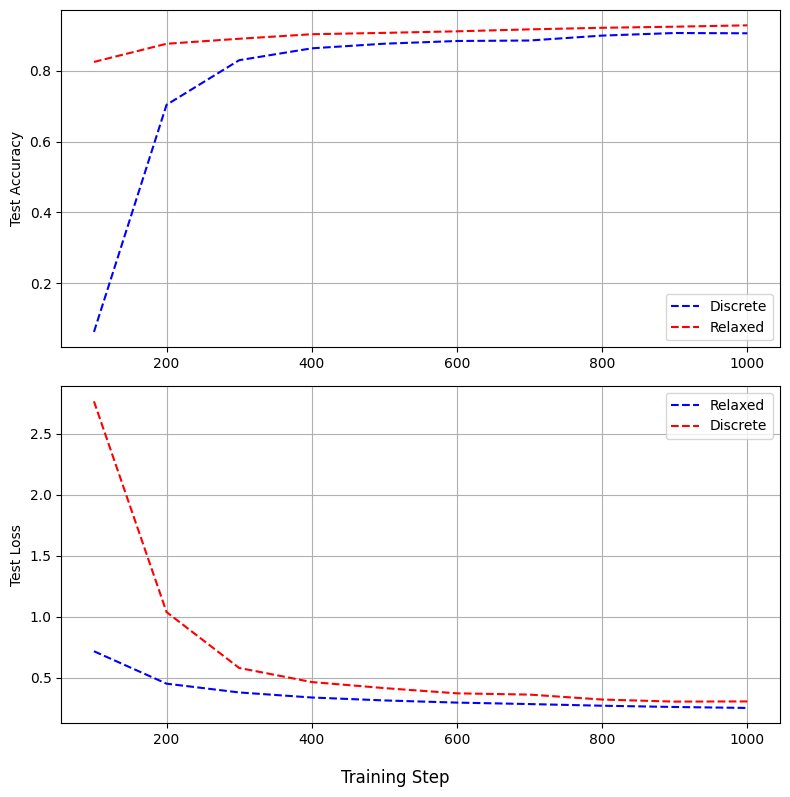

In [23]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8))
axs[0].plot(metrics_dict["step"], metrics_dict["test_acc_discrete"], "--", c="b", label="Discrete")
axs[0].plot(metrics_dict["step"], metrics_dict["test_acc_relaxed"], "--", c="r", label="Relaxed")
axs[0].set_ylabel("Test Accuracy")
axs[0].grid()
axs[0].legend()

axs[1].plot(metrics_dict["step"], metrics_dict["test_loss_relaxed"], "--", c="b", label="Relaxed")
axs[1].plot(metrics_dict["step"], metrics_dict["test_loss_discrete"], "--", c="r", label="Discrete")
axs[1].legend()
axs[1].set_ylabel("Test Loss")
axs[1].grid()
fig.supxlabel("Training Step")
plt.tight_layout()


## Run a Custom Bitmap Through the Trained Model

Set `image_path` to a local bitmap, PNG, or JPG containing a digit. If the image already uses white-on-black styling like MNIST, leave `invert=True`; otherwise change it to `False`.

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

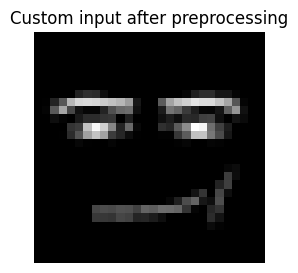

In [24]:
image_path = "BDFM.bmp"
invert = True

pil_image, custom_x = preprocess_bitmap(image_path, invert=invert)
custom_x = custom_x.to(device)

plt.figure(figsize=(3, 3))
plt.imshow(custom_x[0, 0].detach().cpu(), cmap="gray")
plt.title("Custom input after preprocessing")
plt.axis("off")


In [11]:
model.eval()

with torch.no_grad():
    custom_logits = model(custom_x)
    predicted_digit = custom_logits.argmax(dim=-1).item()

print("Predicted digit:", predicted_digit)
print("Class scores:", custom_logits.detach().cpu())


Predicted digit: 7
Class scores: tensor([[20.0000, 16.2500, 15.5000, 19.6250, 15.2500, 22.2500, 15.8750, 22.8750,
         19.0000, 16.1250]])


In [12]:
with torch.no_grad():
    custom_bin = model[0](custom_x)
    custom_conv = model[1](custom_bin)

print("custom input shape:", tuple(custom_x.shape))
print("after binarization:", tuple(custom_bin.shape))
print("after first conv:", tuple(custom_conv.shape))


custom input shape: (1, 1, 28, 28)
after binarization: (1, 1, 28, 28)
after first conv: (1, 16, 26, 26)


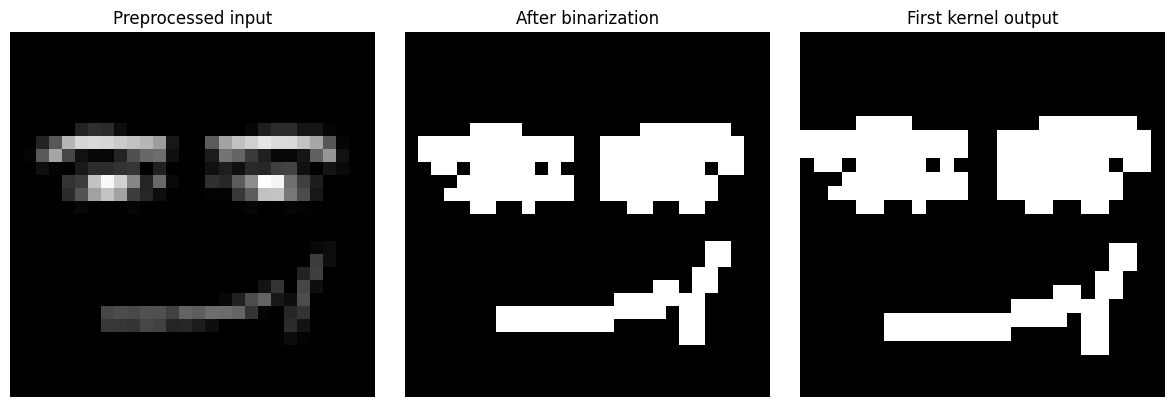

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(custom_x[0, 0].detach().cpu(), cmap="gray")
axes[0].set_title("Preprocessed input")
axes[0].axis("off")

axes[1].imshow(custom_bin[0, 0].detach().cpu(), cmap="gray")
axes[1].set_title("After binarization")
axes[1].axis("off")

axes[2].imshow(custom_conv[0, 0].detach().cpu(), cmap="gray")
axes[2].set_title("First kernel output")
axes[2].axis("off")

plt.tight_layout()


In [1]:
show_kernel_maps(custom_conv, title_prefix="Kernel")


NameError: name 'show_kernel_maps' is not defined